## Pendekatan Terbuka

Selain dari pendekatan tertutup, metode numerik untuk mendapatkan nilai akar juga dapat dilakukan dengan pendekatan terbuka. Pendekatan terbuka dilakukan dengan hanya memberikan satu nilai awal untuk mendapatkan nilai akar, tanpa harus memberikan dua batasan nilai seperti yang digunakan pada pendekatan tertutup. Ada tiga metode yang digunakan pada pendekatan terbuka, yaitu metode iterasi fixed-point, metode newton-raphson, dan metode secant. Ketika mdetode ini akan dijelaskan sebagai berikut.

### Iterasi Fixed-Point

Metode Iterasi Fixed-Point dilakukan dengan mengubah persamaan $f(x) = 0$ menjadi bentuk penyederhanaan lainnya, seperti $x = g(x)$. Ada syarat bahwa $|g'(x)| < 1$ akan konvergen menuju hasil yang ingin dicapai, yaitu nilai akar dari fungsi aslinya.

Misalnya, diketahui suatu persamaan sebagai berikut

$ f(x) = x^3 - x - 2 $

maka persamaan tersebut diubah menjadi

$ x^3 - x - 2 = 0 $

$ -x = -x^3 + 2 $

$ x = x^3 - 2 $

Persamaan $4$ kemudian dicek konvergensinya dengan turunan pertama dari fungsi tersebut, jika

$ g(x) = x^3 - 2 $

maka

$ g'(x) = 3x^2 $

asumsi bahwa nilai akar adalah $x=0$, subtitusikan ke persamaan $6$, maka

$ g'(x) = 3 . (0)^2 = 0 $

hasil persamaan $7$, $0 < 1$. Kita cek lagi untuk $x=1$

$ g'(x) = 3 . (1)^2 = 3 $

ternyata hasilnya $3 > 1$, maka persamaan $7$ tidak memenuhi syarat $|g'(x)| < 1$. Maka, persamaan $2$ harus dicari bentuk penyederhanaan yang lain.

Bentuk dari persamaan $1$ lainnya adalah

$ x = (x + 2)^{1/3} $

Persamaan $9$ diuji, apakah $|g'(x)| < 1$. Untuk menurunkan persamaan $9$ bisa menggunakan aturan rantai $n[u(x)]^{n-1} . u'(x)$, dimana

$ u(x) = x + 2 $

$ u'(x) = 1 $

$ n = \frac {1}{3}$

$ g'(x) = \frac {1}{3} (x + 2)^{-2/3} . 1 = \frac {1}{3} (x + 2)^{-2/3} = \frac {1}{3 . (x + 2)^{2/3}} $

jika $x=0$, maka

$ g'(x) = \frac {1}{3 . (0 + 2)^{2/3}} = \frac {1}{3 . (2)^{2/3}} = 0.21 $

jika $x=1$, maka

$ g'(x) = \frac {1}{3 . (1 + 2)^{2/3}} = \frac {1}{3 . (3)^{2/3}} = 0.16 $

Persamaan $10$ dengan mensubtitusikan nilai $x=0$, $x=1$ memberikan hasil $|g'(x)| < 1$ untuk setiap perubahan nilai $x$ yang terjadi. Artinya persmanaan $9$ bersifat konvergensi dan bisa digunakan untuk menentukan nilai akar.

Selanjutnya, persamaan $9$ diimplementasikan ke dalam kode program Python sebagai berikut

In [1]:
# Ini fungsi untuk hitung error
def cal_absolute_error(xr,xold):
  return abs((xr-xold)/xr)

In [2]:
# Ini fungsi untuk plot grafik

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

def plot_graphic(xmin, xmax, f, xroot, iterations, errors, title=None, xlabel='x'):
  x = np.linspace(xmin, xmax, 20)

  fig, ax = plt.subplots(figsize=(10,4), ncols=2)

  if title != None:
    plt.suptitle(f"{title}", fontsize=16)

  ax[0].plot(x, f(x), color='k', linewidth=2, label='f(x)')
  ax[0].plot(xroot, f(xroot), '.', color='red', markersize=10, label='root')
  ax[0].set_xlabel(xlabel)
  ax[0].set_ylabel('f(x)')
  # ax[0].xaxis.set_minor_locator(MultipleLocator(0.2))
  # ax[0].yaxis.set_minor_locator(MultipleLocator(1))
  ax[0].grid(which='both')
  ax[0].legend(loc='best')


  ax[1].plot(iterations, errors, color='k', linewidth=2)
  ax[1].set_xlabel('Iteration')
  ax[1].set_ylabel('Absolute Error')
  ax[1].xaxis.set_minor_locator(MultipleLocator(0.5))
  ax[1].yaxis.set_minor_locator(MultipleLocator(0.1))
  ax[1].grid(which='both')

  plt.tight_layout()

Iteration: 1, Error: 1.00000, xr: 1.25992, g(xr): 1.48275, f(xr): -1.25992
Iteration: 2, Error: 1.00000, xr: 1.48275, g(xr): 1.51580, f(xr): -0.22283
Iteration: 3, Error: 0.15028, xr: 1.51580, g(xr): 1.52058, f(xr): -0.03304
Iteration: 4, Error: 0.02180, xr: 1.52058, g(xr): 1.52126, f(xr): -0.00478
Iteration: 5, Error: 0.00314, xr: 1.52126, g(xr): 1.52136, f(xr): -0.00069
Iteration: 6, Error: 0.00045, xr: 1.52136, g(xr): 1.52138, f(xr): -0.00010
Iteration: 7, Error: 0.00007, xr: 1.52138, g(xr): 1.52138, f(xr): -0.00001


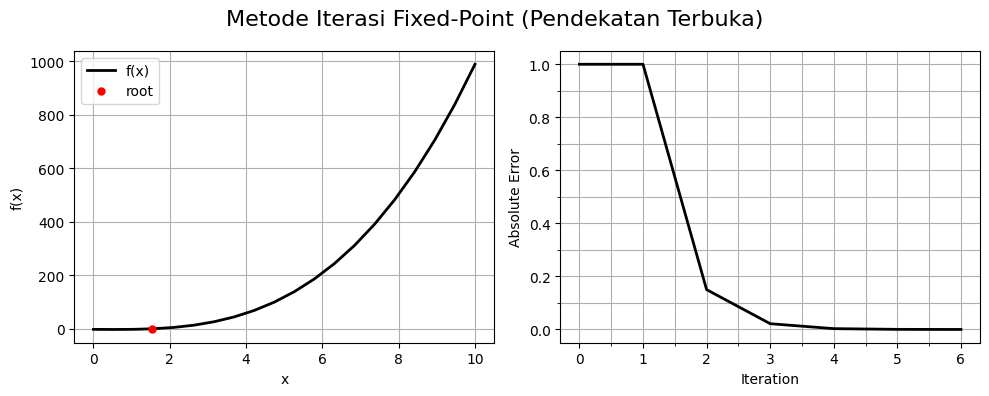

In [3]:
# Metode Iterasi Fixed-Point

# input batas akar
xo = 0

# nilai toleransi error
tol = 1e-5
error = 1

# jumlah iterasi awal
iter = 0

# definisikan fungsi kuadrat
g = lambda x : (x + 2)**(1/3)
f = lambda x: x**3 - x - 2

iteration, errors = [],[]
while error > tol:
  iteration.append(iter)
  errors.append(error)
  x_old = xo
  xr = g(xo)
  iter += 1

  if xr != 0:
    print(f"Iteration: {iter}, Error: {error:.5f}, xr: {xr:.5f}, g(xr): {g(xr):.5f}, f(xr): {f(xr):.5f}")
    error = cal_absolute_error(xr,x_old)

    # perbaharui nilai x
    xo = xr

# Plot grafik
plot_graphic(0,10,f,xr,iteration,errors,title='Metode Iterasi Fixed-Point (Pendekatan Terbuka)')

Berdasarkan hasil yang diperoleh, nilai akar dari fungsi asli (persamaan $1$) adalah $1.521$ setelah 7 kali iterasi dengan nilai galat $0.00002$.

### Newton-Raphson

Metode Newton-Raphson merupakan metode tertutup yang lain untuk menentukan nilai akar. Metode ini diturunkan berdasarkan Deret Taylor yang merupakan jumlah dari kumpulan fungsi dengan urutan tingkatan


_Deret Taylor_

$ f(x) = f(x_0) + f'(x_0)(x - x_0) + \frac {f''(x_0)}{2!} (x - x_0)^2 + \frac {f'''(x_0)}{3!} (x - x_0)^3 + . . . $

dimana $x_0$ adalah suatu nilai awal yang diberikan. Jika $|x - x_0|$ kecil, maka $|x - x_0|^2$ juga terlampau sangat kecil dan dianggap sama dengan nol, maka suku ketiga dan seterusnya bisa dianggap tidak ada, sehingga persamaan $1$ menjadi sebagai berikut

$ f(x) = f(x_0) + f'(x_0)(x - x_0) $

Jika suatu fungsi yang memiliki nilai akar, maka $f(x) = 0$, sehingga

$ 0 = f(x_0) + f'(x_0)(x - x_0) $

$ 0 - f(x_0) = f'(x_0)(x - x_0) $

$ - f(x_0) = f'(x_0)(x - x_0) $

$ - \frac {f(x_0)}{f'(x_0)} = x - x_0 $

$ \frac {f(x_0)}{f'(x_0)} = x_0 - x $

$ x = x_0 - \frac {f(x_0)}{f'(x_0)} $

dimana $x$ adalah estimasi nilai akar yang diinginkan. Jika persamaan $8$ dilakukan perulangan, maka persamaannya menjadi

$ x_{i+1} = x_i - \frac {f(x_i)}{f'(x_i)} $

dimana $i = 0, 1, 2, 3, ..., n$

Sehingga, persamaan $9$ adalah bentuk persamaan yang digunakan untuk menghitung akar pada metode Newton-Raphson. Bentuk turunan pertama pada $f'(x_i)$ akan membentuk garis lurus yang berpotongan dengan fungsi aslinya (tangen). Titik pada garis yang berpotongan tersebut diestimasi sebagai nilai akar dari suatu fungsi $f(x_i)$.

Sebagai contoh, kita gunakan persamaan yang sama seperti sebelumnya, yaitu

$ f(x) = x^3 - x - 2 $

Turunan pertama dari fungsi tersebut adalah

$ f'(x) = 3x^2 - 1 $

dengan nilai awal $ x_0 = 0 $, maka bisa kita hitung estimasi akarnya menggunakan persamaan $9$ sebagai berikut

$ x_{1} = x_0 - \frac {f(x_0)}{f'(x_0)} = x_0 - \frac {x^3 - x - 2}{3x^2 - 1} $

$ x_{1} = 0 - \frac {0^3 - 0 - 2}{3.0^2 - 1} = \frac {-2}{-1} = -2 $

nilai galat dari nilai akar ini adalah

$ error = |\frac {x_{i+1} - x_i} {x_{i+1}}|  = |\frac {-2 - 0}{-2}| = |\frac {-2}{-2}| = 1$

Kemudian nilai $x_0 = x_1 = -2$ untuk menghitung estimasi nilai akar selanjutnya

$ x_{1} = -2 - \frac {-2^3 - (-2) - 2}{3.(-2)^2 - 1} = \frac {-14}{11} = -1.27 $

nilai galat dari nilai akar ini adalah

$ error = |\frac {x_{i+1} - x_i} {x_{i+1}}|  = |\frac {-1.27 - (-2)}{-1.27}| = |\frac {0.73}{-1.27}| = 0.57$

Berdasarkan nilai galat yang diperoleh, nilai galat terus berkurang. Proses ini terus berulang hingga mendapatkan nilai galat yang sangat kecil (lebih kecil dari toleransi yang didefinisikan, misalnya $1e^{-5}$). Perhitungan nilai akar menggunakan metode Newton-Raphson diterapkan ke dalam pemrograman Python adalah sebagai berikut

Iterasi: 1, Error: 1.00000, xo: 0.00000, xr: -2.00000, f(xr): -8.00000
Iterasi: 2, Error: 1.00000, xo: -2.00000, xr: -1.27273, f(xr): -2.78888
Iterasi: 3, Error: 0.57143, xo: -1.27273, xr: -0.55013, f(xr): -1.61636
Iterasi: 4, Error: 1.31352, xo: -0.55013, xr: -18.10357, f(xr): -5917.14939
Iterasi: 5, Error: 0.96961, xo: -18.10357, xr: -12.07930, f(xr): -1752.40507
Iterasi: 6, Error: 0.49873, xo: -12.07930, xr: -8.06673, f(xr): -518.85183
Iterasi: 7, Error: 0.49742, xo: -8.06673, xr: -5.39521, f(xr): -153.65008
Iterasi: 8, Error: 0.49516, xo: -5.39521, xr: -3.61530, f(xr): -45.63825
Iterasi: 9, Error: 0.49233, xo: -3.61530, xr: -2.42094, f(xr): -13.76803
Iterasi: 10, Error: 0.49335, xo: -2.42094, xr: -1.59068, f(xr): -4.43415
Iterasi: 11, Error: 0.52195, xo: -1.59068, xr: -0.91790, f(xr): -1.85546
Iterasi: 12, Error: 0.73296, xo: -0.91790, xr: 0.29672, f(xr): -2.27060
Iterasi: 13, Error: 4.09346, xo: 0.29672, xr: -2.78888, f(xr): -20.90272
Iterasi: 14, Error: 1.10639, xo: -2.78888, xr:

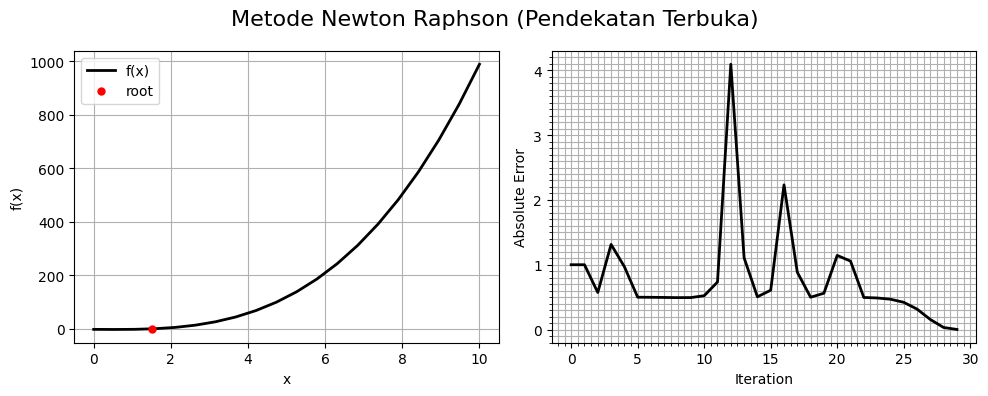

In [4]:
# Metode Newton-Raphson

# input batas akar
xo = 0

# nilai toleransi error
tol = 1e-5
error = 1

# jumlah iterasi awal
iter = 0

# definisikan fungsi kuadrat
f = lambda x: x**3 - x - 2
f1 = lambda x : 3*x**2 - 1

iteration, errors = [], []
while error > tol:
  iteration.append(iter)
  errors.append(error)
  x_old = xo
  xr = xo - ((f(xo))/(f1(xo)))
  iter += 1

  print(f"Iterasi: {iter}, Error: {error:.5f}, xo: {xo:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
  error = cal_absolute_error(xr,x_old)

  # perbaharui nilai x
  xo = xr

# Plot grafik
plot_graphic(0,10,f,xr,iteration,errors,title='Metode Newton Raphson (Pendekatan Terbuka)')

Berdasarkan hasil estimasi nilai akar menggunakan metode Newton Raphson, nilai akar dari fungsi persamaan $10$ adalah $1.52138$ setelah $30$ kali perulangan dengan nilai galat sebesar $0.00119$.

### Metode Secant

Metode ini menggunakan prinsip dua titik untuk menentukan nilai akar, sama seperti metode Regula-Falsi. Namun, metode ini tidak menggunakan syarat bahwa $f(x_i) . f(x_f) < 0$. Persamaan metode ini dapat ditulis sebagai berikut

$$ x_{i+1} = x_i - \frac {f(x_i)(x_{i-1} - x_i)}{f(x_{i-1}) - f(x_i)} $$

dimana $i= 0,1,2,3,...N$

- jika $f(x_{i+1}) = 0$, maka nilai akar dari persamaan terkait adalah $x_{i+1}$
- jika $f(x_{i+1}) \ne 0$, maka nilai estimasi nilai akar berubah menjadi;

  - $x_{i-1} = x_i$

  - $x_i = x_{i+1}$


**Algoritma Metode Secant**

1. Masukan dua nilai tebakan akar awal, $x_{i-1}$ dan $x_i$
2. Definisikan nilai toleransi, $tol = 1e^{-5}$
3. Hitung estimasi nilai akar baru menggunakan persamaan 1
4. Jika $f(x_{i+1}) = 0$
    
    - maka nilai akar dari persamaan terkait adalah $
  
    jika $f(x_{i+1}) \ne 0$

      - maka nilai estimasi nilai akar berubah menjadi;

        - $x_{i-1} = x_i$

        - $x_i = x_{i+1}$

5. Hitung nilai galat absolut
6. Kembali ke poin 3

Sebagai contoh, kita gunakan persamaan yang sama seperti sebelumnya, yaitu

$ f(x) = x^3 - x - 2 $

Iterasi: 1, Error: 1.00000, xo: 3.00000, xr: 0.25000, f(xr): -2.2343750000
Iterasi: 2, Error: 11.00000, xo: 0.25000, xr: 0.50355, f(xr): -2.3758676180
Iterasi: 3, Error: 0.50352, xo: 0.50355, xr: -3.75386, f(xr): -51.1436524730
Iterasi: 4, Error: 1.13414, xo: -3.75386, xr: 0.71096, f(xr): -2.3515960322
Iterasi: 5, Error: 6.28000, xo: 0.71096, xr: 0.92615, f(xr): -2.1317471686
Iterasi: 6, Error: 0.23235, xo: 0.92615, xr: 3.01270, f(xr): 22.3316023947
Iterasi: 7, Error: 0.69259, xo: 3.01270, xr: 1.10797, f(xr): -1.7478306029
Iterasi: 8, Error: 1.71912, xo: 1.10797, xr: 1.24623, f(xr): -1.3107381665
Iterasi: 9, Error: 0.11094, xo: 1.24623, xr: 1.66083, f(xr): 0.9202989972
Iterasi: 10, Error: 0.24963, xo: 1.66083, xr: 1.48980, f(xr): -0.1831602511
Iterasi: 11, Error: 0.11479, xo: 1.48980, xr: 1.51819, f(xr): -0.0189041361
Iterasi: 12, Error: 0.01870, xo: 1.51819, xr: 1.52146, f(xr): 0.0004684278
Iterasi: 13, Error: 0.00215, xo: 1.52146, xr: 1.52138, f(xr): -0.0000011487
Iterasi: 14, Error:

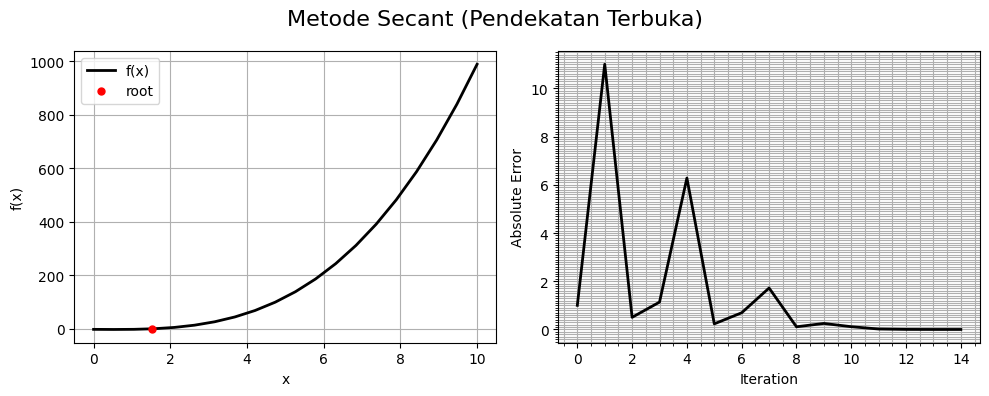

In [5]:
# Metode Secant

# input batas akar
xo = -3
xi = 3

# nilai toleransi error
tol = 1e-10
error = 1

# jumlah iterasi awal
iter = 0

# definisikan fungsi kuadrat
f = lambda x: x**3 - x - 2

iteration, errors = [], []
while error > tol:
  iteration.append(iter)
  errors.append(error)
  x_old = xi

  xr = xi - ((f(xi) * (xo-xi))/(f(xo) - f(xi)))

  if f(xr) == 0:
    xr = xr
  else:
    xo, xi = xi, xr

  iter += 1

  print(f"Iterasi: {iter}, Error: {error:.5f}, xo: {xo:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.10f}")
  error = abs((xr - x_old) / xr)

# Plot grafik
plot_graphic(0,10,f,xr,iteration,errors,title='Metode Secant (Pendekatan Terbuka)')

### Contoh Kasus Pada Gerak Parabola

Berapa lama waktu yang ditempuh oleh suatu roket untuk mencapai ketinggian 42.100 m jika diketahui posisi awalnya ($h_0$) adalah pada ketinggian 100 m, kecepatan awal ($v_0$) adalah 1000 m/s, dan percepatan gravitasinya ($g$) adalah 10 $m/s^2$. Kondisi ini memenuhi persamaan sebagai berikut

$h = h_0 + v_0t - \frac {1}{2} g t^2$

**Penyelesaian**

Dari persamaan di atas, persamaan tersebut harus dilakukan penyesuaian untuk memmbentuk persamaan kuadrat yang sama dengan $0$ sebagai berikut

$42100 = 100 + 1000t - \frac {1}{2} 10 t^2$

$0 = 100 - 42100 + 1000t - \frac {1}{2} 10 t^2$

$0 = -42000 + 1000t - \frac {1}{2} 10 t^2$

$0 = - \frac {1}{2} 10 t^2 + 1000t - 42000 $

Persamaan terakhir akan digunakan untuk mengestimasi waktu tempuh roket menggunakan tiga metode numerik pendekatan terbuka di atas. Asumsi bahwa waktu tempuh tidak kurang dari 0 s, maka asumsi nilai batas awal ($x_i = 0$) dan batas akhir ($x_f = 100$) dan nilai toleransi diatur sebesar $1e-5$.

Kita coba selesaikan persamaan di atas menggunakan metode Newton-Raphson sebagai berikut dengan memberikan nilai awal, $x_o = 40$.

Iterasi: 1, Error: 1.00000, xo: 40.00000, xr: 56.66667, f(xr): -1388.88889
Iterasi: 2, Error: 0.29412, xo: 56.66667, xr: 59.87179, f(xr): -51.36423
Iterasi: 3, Error: 0.05353, xo: 59.87179, xr: 59.99980, f(xr): -0.08192
Iterasi: 4, Error: 0.00213, xo: 59.99980, xr: 60.00000, f(xr): -0.00000


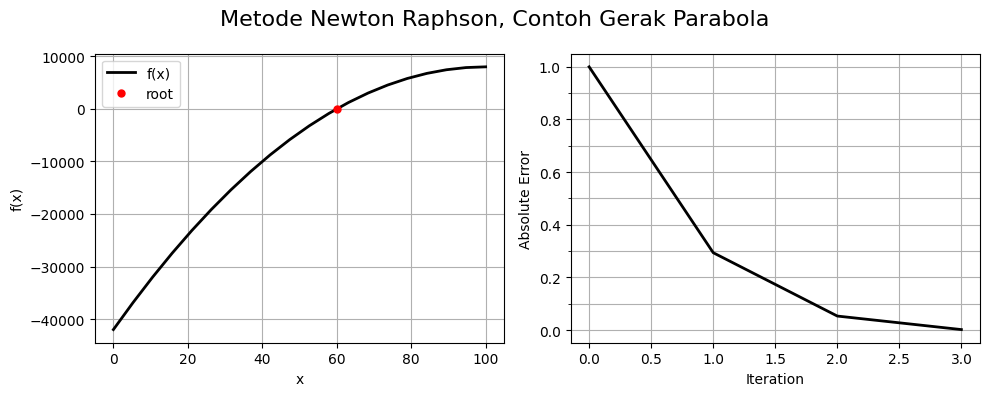

In [6]:
# Metode Newton-Raphson

# input batas akar
xo = 40

# nilai toleransi error
tol = 1e-5
error = 1

# jumlah iterasi awal
iter = 0

# definisikan fungsi kuadrat
f = lambda t: (-0.5*10)*(t**2) + 1000*t - 42000
f1 = lambda t : -10*t + 1000

iteration, errors = [], []
while error > tol:
  iteration.append(iter)
  errors.append(error)
  x_old = xo
  xr = xo - ((f(xo))/(f1(xo)))
  iter += 1

  print(f"Iterasi: {iter}, Error: {error:.5f}, xo: {xo:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
  error = cal_absolute_error(xr,x_old)

  # perbaharui nilai x
  xo = xr

# Plot grafik
plot_graphic(0,100,f,xr,iteration,errors,title='Metode Newton Raphson, Contoh Gerak Parabola')

Berdasarkan metode newton raphson, waktu yang diperlukan roket untuk mencapai pada ketinggian 42.100 adalah 59.99 s dengan nilai galat 0.00213. Untuk membuktikannya, kita bisa mensubtitusikan nilai 59.99 s ke dalam persamaan aslinya

$h = 100 + 1000*(59.99) - \frac {1}{2} 10 (59.99)^2 = 42095.9995$

In [7]:
h = 100 + (1000*59.99) - (0.5 * 10 * 59.99**2)
print(h)

42095.9995


Selanjutnya, kita coba selesaikan persamaan yang sama di atas menggunakan metode secant dengan memberikan nilai batas dari $x_o = 10$ dan $x_i = 100$ sebagai berikut.

Iterasi: 1, Error: 1.00000, xo: 100.00000, xr: 82.22222, f(xr): 6419.7530864198
Iterasi: 2, Error: 0.21622, xo: 82.22222, xr: 10.00000, f(xr): -32500.0000000004
Iterasi: 3, Error: 7.22222, xo: 10.00000, xr: 70.30928, f(xr): 3592.3052396642
Iterasi: 4, Error: 0.85777, xo: 70.30928, xr: 64.30663, f(xr): 1629.9174803271
Iterasi: 5, Error: 0.09334, xo: 64.30663, xr: 59.32096, f(xr): -273.9205940989
Iterasi: 6, Error: 0.08405, xo: 59.32096, xr: 60.03829, f(xr): 15.3090188268
Iterasi: 7, Error: 0.01195, xo: 60.03829, xr: 60.00032, f(xr): 0.1289712633
Iterasi: 8, Error: 0.00063, xo: 60.00032, xr: 60.00000, f(xr): -0.0000617603
Iterasi: 9, Error: 0.00001, xo: 60.00000, xr: 60.00000, f(xr): 0.0000000002
Iterasi: 10, Error: 0.00000, xo: 60.00000, xr: 60.00000, f(xr): 0.0000000000


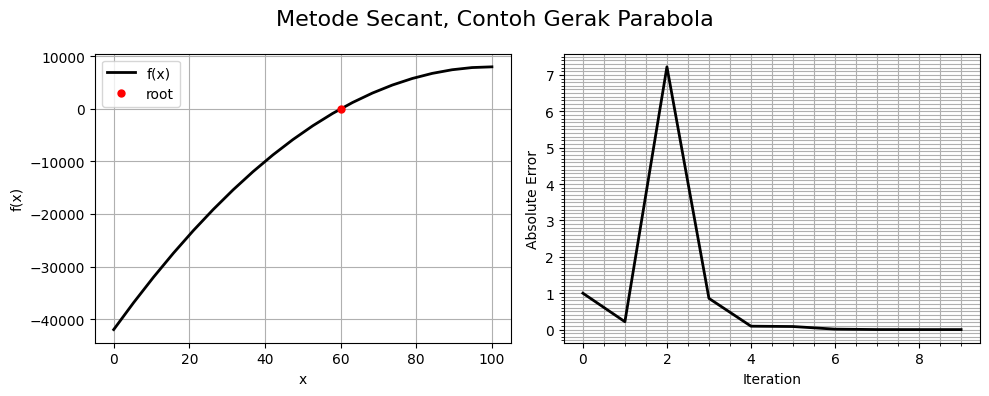

In [8]:
# Metode Secant

# input batas akar
xo = 10
xi = 100

# nilai toleransi error
tol = 1e-10
error = 1

# jumlah iterasi awal
iter = 0

# definisikan fungsi kuadrat
f = lambda t: (-0.5*10)*(t**2) + 1000*t - 42000

iteration, errors = [], []
while error > tol:
  iteration.append(iter)
  errors.append(error)
  x_old = xi

  xr = xi - ((f(xi) * (xo-xi))/(f(xo) - f(xi)))

  if f(xr) == 0:
    xr = xr
  else:
    xo, xi = xi, xr

  iter += 1

  print(f"Iterasi: {iter}, Error: {error:.5f}, xo: {xo:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.10f}")
  error = abs((xr - x_old) / xr)

# Plot grafik
plot_graphic(0,100,f,xr,iteration,errors,title='Metode Secant, Contoh Gerak Parabola')


Berdasarkan metode secant, waktu yang diperlukan roket untuk mencapai pada ketinggian 42.100 adalah 60 s dengan nilai galat 0.00000 setelah mencapai iterasi ke-10. Untuk membuktikannya, kita bisa mensubtitusikan nilai 60 s ke dalam persamaan aslinya

$h = 100 + 1000*(60) - \frac {1}{2} 10 (60)^2 = 42100$

In [9]:
h = 100 + (1000*60) - (0.5 * 10 * 60**2)
print(h)

42100.0


Sekarang, coba kita selesaikan persamaan di atas menggunakan metode iterasi fixed-point. Sebelum itu, kita cek terlebih dahulu apakah persamaan tersebut memiliki bentuk yang konvergensi berdasarkan $|g'(x)| < 1$ sebagai berikut.

Persamaan asli

$f(t) = -\frac {1}{2} 10 t^2 + 1000t - 42000$

Kita rubah benruk persamaan asli menjadi bentuk yang lain sebagi berikut

Bentuk 1

$f(t) = -\frac {1}{2} 10 t^2 + 1000t - 42000$

$0 = -\frac {1}{2} 10 t^2 + 1000t - 42000$

$1000t = \frac {1}{2} 10 t^2 + 42000$

$t = 0.005t^2 + 42$

$g(t) = 0.005t^2 + 42$

$g'(t) = \frac {d}{dt} (0.005t^2 + 42) = 0.01t$, ini adalah bentuk 1 dari persamaan asli.

Bentuk 1 terlihat sebagai fungsi yang linear. Artinya, setiap peningkatan nilai $t$ maka nilai $g'(t)$ juga akan ikut meningkat. Hal ini tidak memenuhi $|g'(t)| < 1$. Maka dari itu, persamaan bentuk 1 tidak terpenuhi syaratnya. Kita coba untuk merubah persamaan asli menjadi bentuk kedua sebagai berikut.

Bentuk 2

$f(t) = -\frac {1}{2} 10 t^2 + 1000t - 42000$

$\frac {1}{2} 10t^2 = 1000t - 42000$

$t^2 = 200t - 8400$

$t = (200t - 8400)^{1/2}$

$g(t) = (200t - 8400)^{1/2}$, ini adalah bentuk 2 dari persamaan asli di atas. Kemudian, kita coba cek apakah bentuk 2 ini memenuhi syarat yang berlaku $|g'(t) < 1|$.

Untuk mendapatkan turunan $g'(t)$, kita terapkan aturan rantai $n(u(t))^{n-1} u'(t)$, dimana

$n=\frac {1}{2}$

$u(t) = 200t - 8400$

$u'(t) = 200$

maka

$g'(t) = \frac {1}{2} (200t - 8400)^{\frac {1}{2} -1} . 200$

$g'(t) = \frac {1}{2} (200t - 8400)^{-\frac {1}{2}} . 200$

$g'(t) = (200t - 8400)^{-\frac {1}{2}} . 100$

$g'(t) = \frac {100} {(200t - 8400)^{\frac {1}{2}}}$

Sekarang, coba kita cek $g'(t)$ dengan memberikan nilai $t=0$

$g'(t=0) = \frac {100} {(200 . 0 - 8400)^{\frac {1}{2}}} = \frac {100} {(-8400)^{\frac {1}{2}}} = invalid$

karena penyebutnya bernilai negatif dan memiliki pangkat $\frac {1}{2}$, maka penyebut tidak bisa diselesaikan, sehingga $g'(t)$ juga tidak bisa diselesaikan. Artinya, persamaan ini tidak bisa diselesaikan menggunakan metode iterasi fixed-point.